In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch

import hdbscan

Section 1: Data Loading

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [5]:
df.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape

(200, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Section 2: Exploratory Data Analysis

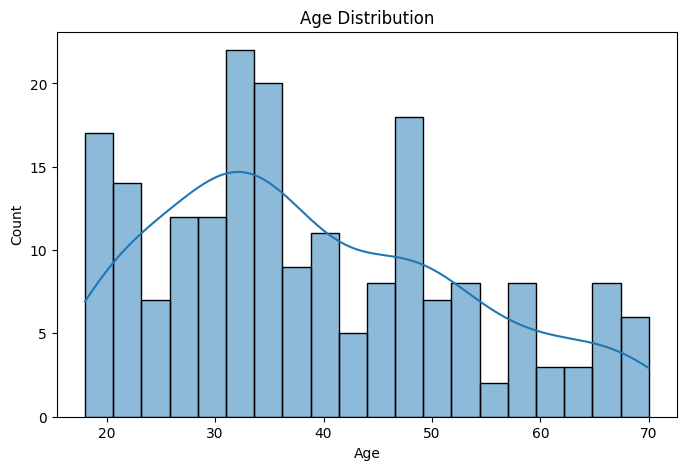

In [16]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.show()

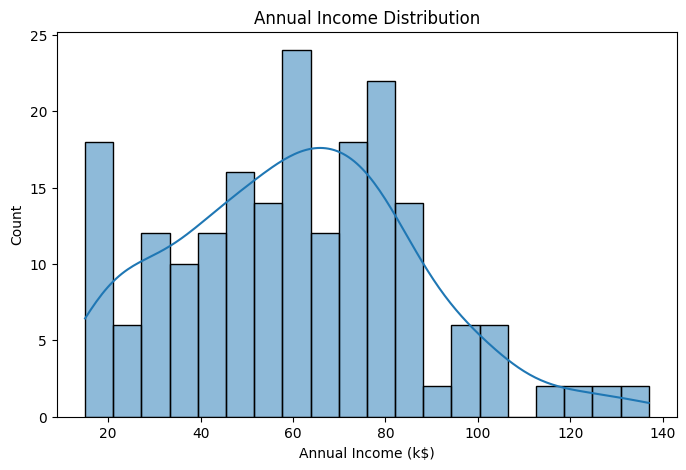

In [17]:
#Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True
)

plt.title('Annual Income Distribution')

plt.show()

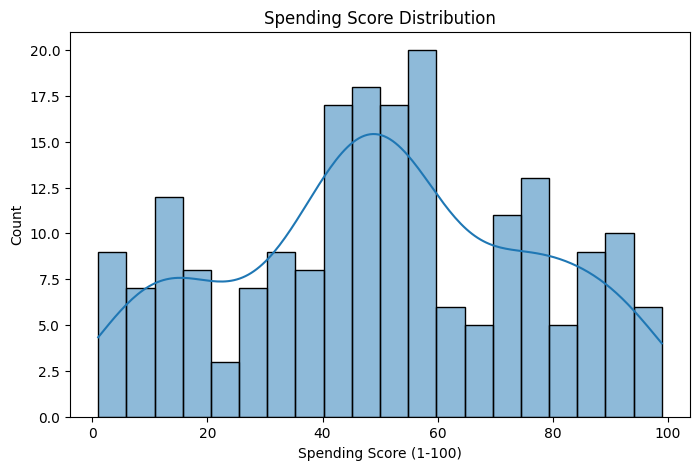

In [18]:
#Spending Score Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')

plt.show() 

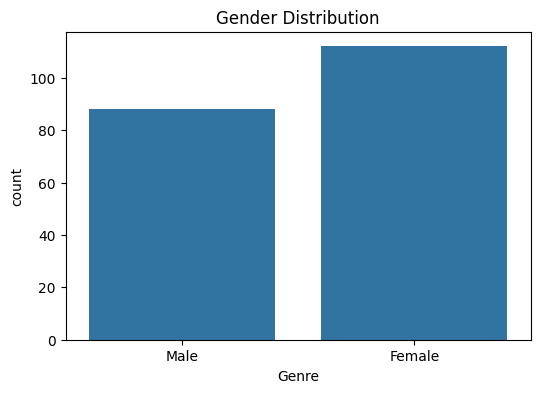

In [21]:
#Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Genre', data=df)

plt.title('Gender Distribution')

plt.show()

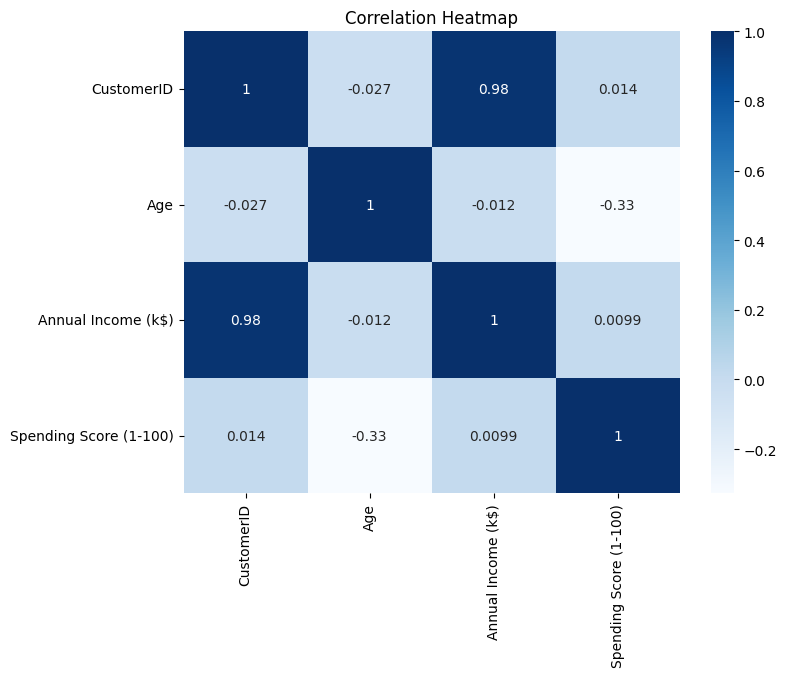

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap( df.select_dtypes(include=np.number).corr(), annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

Section 3: Feature Selection & Feature Scaling

In [22]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [24]:
X.head(5)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

Section 4: Elbow Method

In [26]:
wcss = []

In [27]:
for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

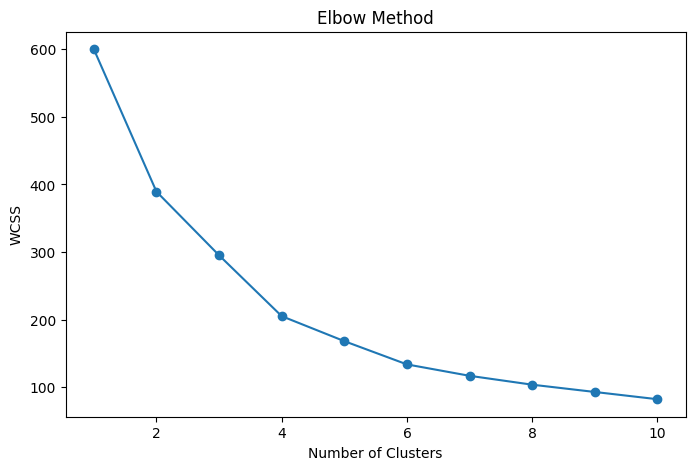

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [29]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(
        f"K={k}, Score={score:.3f}"
    )

K=2, Score=0.335
K=3, Score=0.358
K=4, Score=0.404
K=5, Score=0.417
K=6, Score=0.428
K=7, Score=0.417
K=8, Score=0.408
K=9, Score=0.418
K=10, Score=0.407


C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

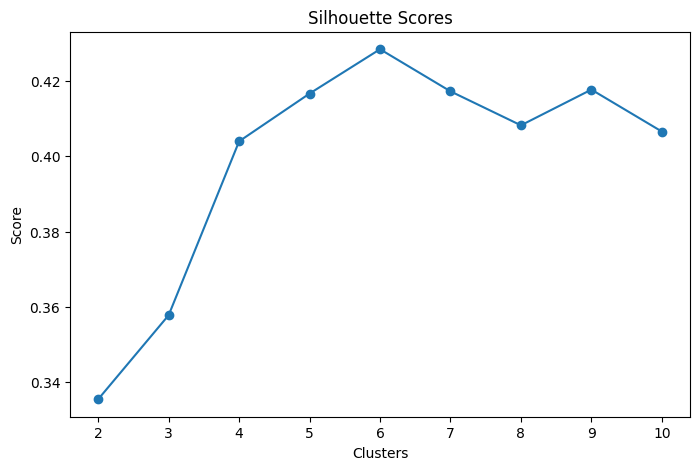

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.title("Silhouette Scores")

plt.xlabel("Clusters")

plt.ylabel("Score")

plt.show()

Section 6: K-Means Clustering

In [31]:
#model training
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [33]:
df['KMeans_Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


In [34]:
df['KMeans_Cluster'].value_counts().sort_index()

KMeans_Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Section 7: visulizations

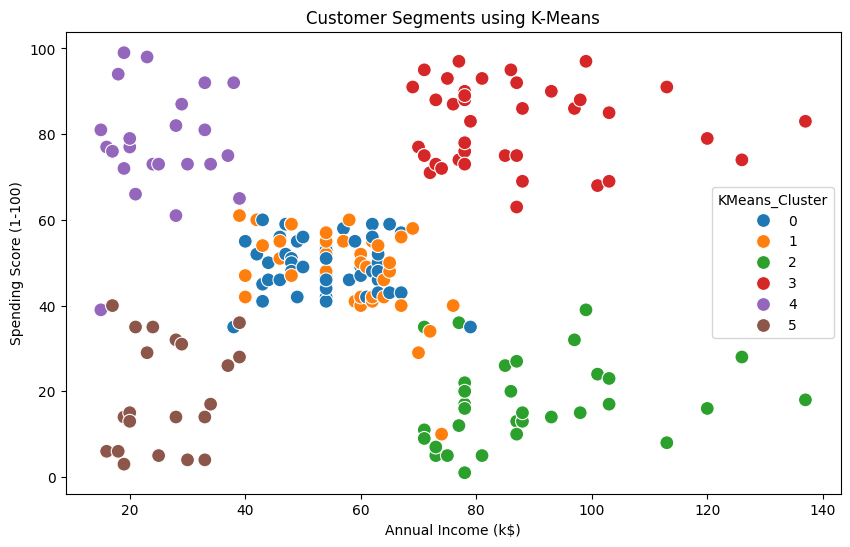

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='tab10',
    data=df,
    s=100
)

plt.title("Customer Segments using K-Means")

plt.show()

In [36]:
#Cluster Profiling
cluster_summary = df.groupby(
    'KMeans_Cluster'
)[
[
'Age',
'Annual Income (k$)',
'Spending Score (1-100)'
]
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [39]:
cluster_names = {
    0: "Older Average Customers",
    1: "Young Regular Customers",
    2: "High Income Low Spending",
    3: "Premium Customers",
    4: "Loyal Budget Customers",
    5: "Budget Customers"
}

df['Customer_Type'] = df['KMeans_Cluster'].map(cluster_names)

df[['KMeans_Cluster','Customer_Type']].head()

,KMeans_Cluster,Customer_Type
0,4,Loyal Budget Customers
1,4,Loyal Budget Customers
2,5,Budget Customers
3,4,Loyal Budget Customers
4,5,Budget Customers


In [40]:
business_insights = pd.DataFrame({

    'Customer Type': [
        'Premium Customers',
        'High Income Low Spending',
        'Loyal Budget Customers',
        'Budget Customers',
        'Young Regular Customers',
        'Older Average Customers'
    ],

    'Marketing Strategy': [
        'VIP Memberships, Exclusive Products, Premium Rewards',
        '1+1 Offers, Personalized Recommendations, Re-engagement Campaigns',
        'Loyalty Points, Cashback Rewards, Referral Programs',
        'Discount Coupons, Budget Deals, Festival Offers',
        'Seasonal Promotions, New Product Launches',
        'Family Packages, Long-Term Membership Benefits'
    ]
})

business_insights

,Customer Type,Marketing Strategy
0,Premium Customers,"VIP Memberships, Exclusive Products, Premium R..."
1,High Income Low Spending,"1+1 Offers, Personalized Recommendations, Re-e..."
2,Loyal Budget Customers,"Loyalty Points, Cashback Rewards, Referral Pro..."
3,Budget Customers,"Discount Coupons, Budget Deals, Festival Offers"
4,Young Regular Customers,"Seasonal Promotions, New Product Launches"
5,Older Average Customers,"Family Packages, Long-Term Membership Benefits"


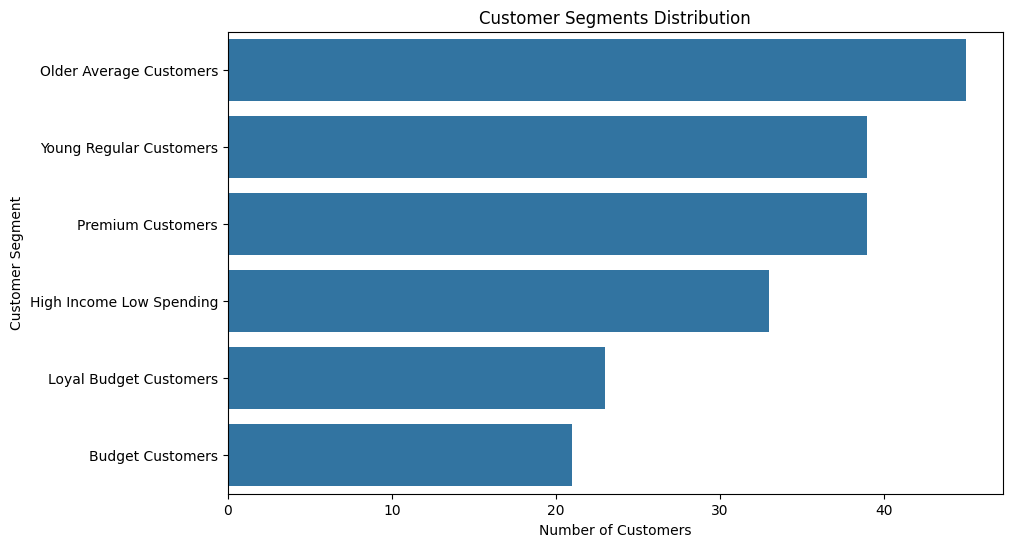

In [41]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Customer_Type',
    data=df,
    order=df['Customer_Type'].value_counts().index
)

plt.title('Customer Segments Distribution')

plt.xlabel('Number of Customers')

plt.ylabel('Customer Segment')

plt.show()

Section 8: Hierarchical Clustering

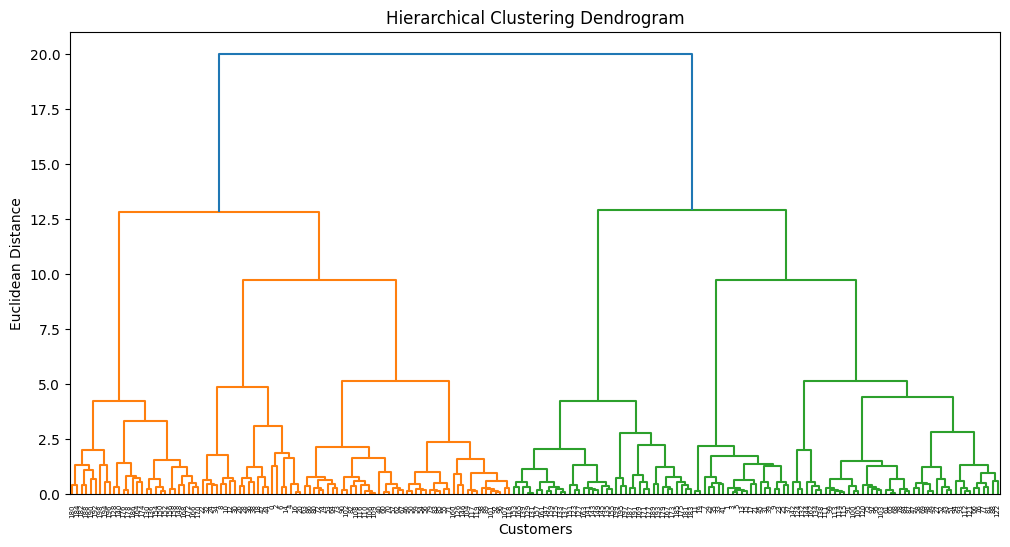

In [42]:
plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(
        X_scaled,
        method='ward'
    )
)

plt.title('Hierarchical Clustering Dendrogram')

plt.xlabel('Customers')

plt.ylabel('Euclidean Distance')

plt.show()

In [43]:
#model creation
hc = AgglomerativeClustering(
    n_clusters=6
)

hc_labels = hc.fit_predict(X_scaled)

In [45]:
df['HC_Cluster'] = hc_labels

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Customer_Type,HC_Cluster
0,1,Male,19,15,39,4,Loyal Budget Customers,4
1,2,Male,21,15,81,4,Loyal Budget Customers,5
2,3,Female,20,16,6,5,Budget Customers,4
3,4,Female,23,16,77,4,Loyal Budget Customers,5
4,5,Female,31,17,40,5,Budget Customers,4


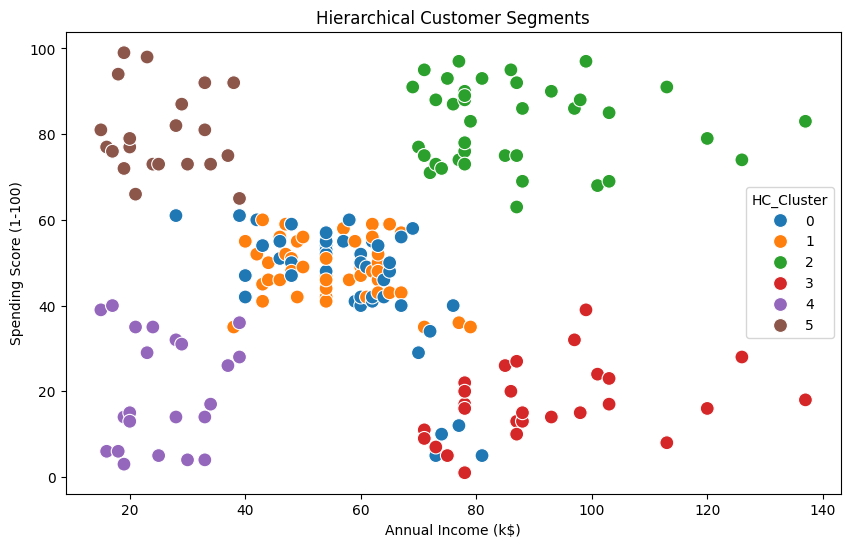

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HC_Cluster',
    palette='tab10',
    data=df,
    s=100
)

plt.title("Hierarchical Customer Segments")

plt.show()

In [47]:
hc_score = silhouette_score(
    X_scaled,
    hc_labels
)

print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.4201169558789579


comparison of Hierarchical Clustering with k-mean 

In [48]:
kmeans_score = silhouette_score(X_scaled, clusters)

print("KMeans :", kmeans_score)
print("Hierarchical :", hc_score)

KMeans : 0.4284167762892593
Hierarchical : 0.4201169558789579


In [49]:
comparison = pd.DataFrame({

    'Algorithm':[
        'KMeans',
        'Hierarchical'
    ],

    'Silhouette Score':[
        kmeans_score,
        hc_score
    ]
})

comparison

,Algorithm,Silhouette Score
0,KMeans,0.428417
1,Hierarchical,0.420117


Section 9: DBSCAN to detect outliers

In [50]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

In [51]:
dbscan_labels = dbscan.fit_predict(X_scaled)

In [53]:
df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].unique())

[-1  0]


In [54]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    194
-1      6
Name: count, dtype: int64

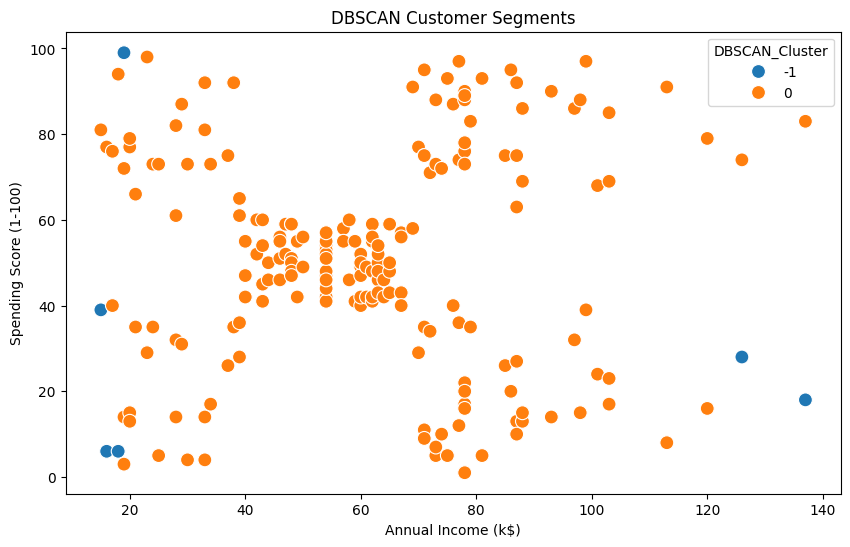

In [55]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    palette='tab10',
    data=df,
    s=100
)

plt.title("DBSCAN Customer Segments")

plt.show()

In [56]:
len(set(dbscan_labels))

2

In [57]:
dbscan_score = silhouette_score(
    X_scaled,
    dbscan_labels
)

print("DBSCAN Score:", dbscan_score)

DBSCAN Score: 0.2543987042290558


In [59]:
#outliers
noise_customers = df[
    df['DBSCAN_Cluster'] == -1
]

noise_customers.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Customer_Type,HC_Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,4,Loyal Budget Customers,4,-1
2,3,Female,20,16,6,5,Budget Customers,4,-1
6,7,Female,35,18,6,5,Budget Customers,4,-1
11,12,Female,35,19,99,4,Loyal Budget Customers,5,-1
196,197,Female,45,126,28,2,High Income Low Spending,3,-1


Section 10: HDBSCAN

In [60]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

hdb_labels = hdb.fit_predict(X_scaled)

In [61]:
df['HDBSCAN_Cluster'] = hdb_labels

print(df['HDBSCAN_Cluster'].unique())

[-1  2  1  3  0]


In [62]:
df['HDBSCAN_Cluster'].value_counts().sort_index()

HDBSCAN_Cluster
-1    79
 0    33
 1    48
 2    14
 3    26
Name: count, dtype: int64

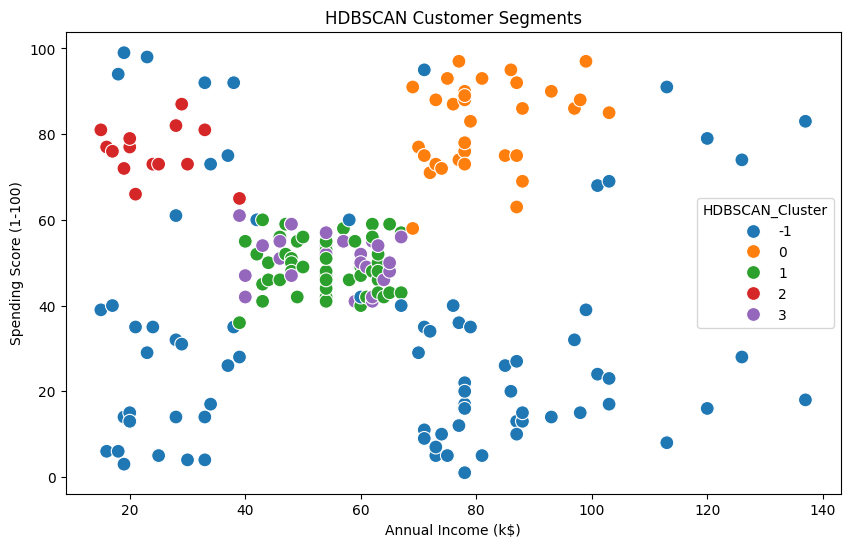

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HDBSCAN_Cluster',
    palette='tab10',
    data=df,
    s=100
)

plt.title("HDBSCAN Customer Segments")

plt.show()

In [64]:
valid_points = hdb_labels != -1

hdb_score = silhouette_score(
    X_scaled[valid_points],
    hdb_labels[valid_points]
)

print("HDBSCAN Score:", hdb_score)

HDBSCAN Score: 0.5446887294786402


In [65]:
hdb_summary = df[df['HDBSCAN_Cluster'] != -1].groupby(
    'HDBSCAN_Cluster'
)[
[
'Age',
'Annual Income (k$)',
'Spending Score (1-100)'
]
].mean().round(2)

hdb_summary

,Age,Annual Income (k$),Spending Score (1-100)
HDBSCAN_Cluster,,,
0,32.73,81.00,81.88
1,54.54,54.08,49.15
2,24.00,24.00,75.86
3,23.73,54.12,50.73


In [67]:
noise_customers = df[df['HDBSCAN_Cluster'] == -1]

noise_customers.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Customer_Type,HC_Cluster,DBSCAN_Cluster,HDBSCAN_Cluster
0,1,Male,19,15,39,4,Loyal Budget Customers,4,-1,-1
2,3,Female,20,16,6,5,Budget Customers,4,-1,-1
4,5,Female,31,17,40,5,Budget Customers,4,0,-1
6,7,Female,35,18,6,5,Budget Customers,4,-1,-1
7,8,Female,23,18,94,4,Loyal Budget Customers,5,0,-1


In [70]:
print("HDBSCAN Score:", hdb_score)

hdb_summary

HDBSCAN Score: 0.5446887294786402


,Age,Annual Income (k$),Spending Score (1-100)
HDBSCAN_Cluster,,,
0,32.73,81.00,81.88
1,54.54,54.08,49.15
2,24.00,24.00,75.86
3,23.73,54.12,50.73


In [71]:
segment_summary = pd.DataFrame({
    'Cluster': hdb_summary.index,
    'Average Age': hdb_summary['Age'],
    'Average Income': hdb_summary['Annual Income (k$)'],
    'Average Spending': hdb_summary['Spending Score (1-100)']
})

segment_summary

,Cluster,Average Age,Average Income,Average Spending
HDBSCAN_Cluster,,,,
0,0,32.73,81.00,81.88
1,1,54.54,54.08,49.15
2,2,24.00,24.00,75.86
3,3,23.73,54.12,50.73


In [72]:
marketing_strategy = pd.DataFrame({
    'Customer Segment': [
        'Premium Customers',
        'High Income Low Spending',
        'Loyal Budget Customers',
        'Budget Customers',
        'Regular Customers'
    ],
    'Recommended Strategy': [
        'VIP Memberships, Premium Products, Exclusive Rewards',
        'Personalized Offers, 1+1 Campaigns',
        'Cashback, Loyalty Programs',
        'Discount Coupons and Budget Deals',
        'Seasonal Promotions and Cross-Selling'
    ]
})

marketing_strategy

,Customer Segment,Recommended Strategy
0,Premium Customers,"VIP Memberships, Premium Products, Exclusive R..."
1,High Income Low Spending,"Personalized Offers, 1+1 Campaigns"
2,Loyal Budget Customers,"Cashback, Loyalty Programs"
3,Budget Customers,Discount Coupons and Budget Deals
4,Regular Customers,Seasonal Promotions and Cross-Selling


In [73]:
noise_customers = df[df['HDBSCAN_Cluster'] == -1]

print("Number of Noise Customers:",
      len(noise_customers))

Number of Noise Customers: 79


FINAL SUMMARY COMPARISON FOR ALL ALGORITHMS

In [68]:
comparison = pd.DataFrame({

    'Algorithm':[
        'KMeans',
        'Hierarchical',
        'DBSCAN',
        'HDBSCAN'
    ],

    'Silhouette Score':[
        kmeans_score,
        hc_score,
        dbscan_score,
        hdb_score
    ]
})

comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Algorithm,Silhouette Score
3,HDBSCAN,0.544689
0,KMeans,0.428417
1,Hierarchical,0.420117
2,DBSCAN,0.254399


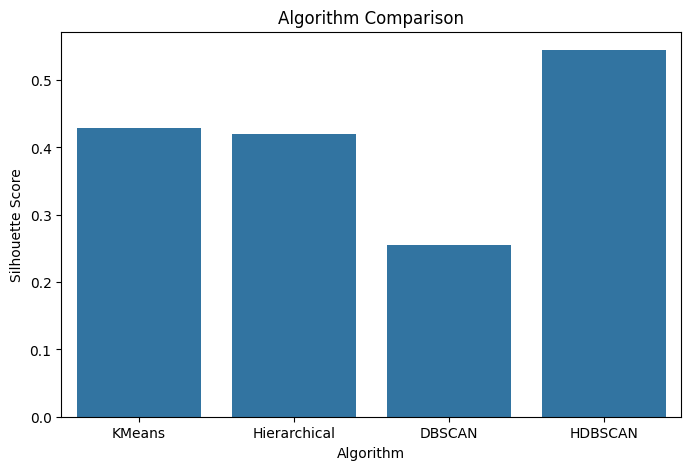

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Algorithm',
    y='Silhouette Score',
    data=comparison
)

plt.title("Algorithm Comparison")

plt.show()

In [74]:
df.to_csv("../data/customer_segments.csv",index=False)